## BIBLIOTECAS E CARREGAMENTO DO ARQUIVO CSV

In [3]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv(
    "mp_controle_prazos_bruto.csv",
    sep = ";",
    encoding="utf-8-sig"
)

df_bruto = df.copy()

## DESMEMBRANDO A TABELA

In [4]:
display(df)

print("\nNome das Colunas")
display(df.columns)

print("\nInformações da Tabela")
print(df.info())

display(df.describe())

print("\nDimensão da base")
print(df.shape)

print("\nTipos das colunas")
display(df.dtypes)

print("\nValores ausentes por coluna")
display(df.isna().sum().sort_values(ascending=False))

print("\nQuantidade inicial de linhas duplicadas: ")
print(df.duplicated().sum())

,id_procedimento,tipo_procedimento,promotoria,area,assunto,municipio,data_abertura,data_ultima_movimentacao,prazo_dias,data_limite,situacao,setor_responsavel,quantidade_movimentacoes,prioridade
0,PROC-2025-0133,Procedimento Preparatório,2ª Promotoria de Justiça,Patrimônio Público,Contrato administrativo,Nova Iguaçu,2025-12-25,22/08/2026,10,04/01/2026,Arquivado,Assessoria Jurídica,11,Normal
1,PROC-2025-0149,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Serviço não prestado,São Gonçalo,18.05.2025,28/10/2025,NaN,23/05/2025,Em andamento,Assessoria Jurídica,9,Alta
2,PROC-2025-0094,Notícia de Fato,Promotoria de Educação,Educação,Estrutura escolar inadequada,Cabo Frio,26/11/2025,21/02/2026,15,11/12/2025,Suspenso,Central de Apoio,9,Alta
3,PROC-2026-0181,NaN,Promotoria de Tutela Coletiva,Urbanismo,Uso irregular do solo,Nova Iguaçu,03/04/2026,25/03/2026,5,16/10/2026,Arquivado,Núcleo Técnico,5,Normal
4,NaN,Notícia de Fato,Promotoria de Tutela Coletiva,NaN,Cobrança em duplicidade,Volta Redonda,10/12/2024,12/02/2025,120,09/04/2025,Em andamento,Central de Apoio,5,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,PROC-2026-0107,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Cobrança em duplicidade,Duque de Caxias,NaN,28/07/2026,60,22/08/2026,Encerrado,Gabinete,8,Alta
216,PROC-2024-0015,Inquérito Civil,1ª Promotoria de Justiça,Patrimônio Público,Irregularidade em contratação,Rio de Janeiro,20/10/2024,23/04/2025,10,30/10/2024,Em andamento,Central de Apoio,12,Urgente
217,PROC-2025-0093,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Cobrança em duplicidade,Rio de Janeiro,20/03/2025,03/04/2025,30,19/04/2025,Em andamento,Ass. Jurídica,NaN,Normal
218,PROC-2025-0180,Inquérito Civil,1ª Promotoria de Justiça,NaN,Acesso a benefício,Rio de Janeiro,04/06/2025,29/03/2026,20,24/06/2025,Em andamento,Central de Apoio,8,NaN



Nome das Colunas


Index(['id_procedimento', 'tipo_procedimento', 'promotoria', 'area', 'assunto',
       'municipio', 'data_abertura', 'data_ultima_movimentacao', 'prazo_dias',
       'data_limite', 'situacao', 'setor_responsavel',
       'quantidade_movimentacoes', 'prioridade'],
      dtype='object')


Informações da Tabela
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id_procedimento           218 non-null    object
 1   tipo_procedimento         209 non-null    object
 2   promotoria                211 non-null    object
 3   area                      208 non-null    object
 4   assunto                   213 non-null    object
 5   municipio                 213 non-null    object
 6   data_abertura             217 non-null    object
 7   data_ultima_movimentacao  210 non-null    object
 8   prazo_dias                192 non-null    object
 9   data_limite               202 non-null    object
 10  situacao                  213 non-null    object
 11  setor_responsavel         208 non-null    object
 12  quantidade_movimentacoes  216 non-null    object
 13  prioridade                209 non-null    object
dtypes: 

,id_procedimento,tipo_procedimento,promotoria,area,assunto,municipio,data_abertura,data_ultima_movimentacao,prazo_dias,data_limite,situacao,setor_responsavel,quantidade_movimentacoes,prioridade
count,218,209,211,208,213,213,217,210,192,202,213,208,216,209
unique,214,25,18,24,62,27,193,173,21,182,18,15,26,13
top,PROC-2026-0039,Procedimento Administrativo,Promotoria de Tutela Coletiva,Urbanismo,Obra irregular,Volta Redonda,24/07/2026,30/06/2026,120,17/10/2026,Em andamento,Assessoria Jurídica,6,Normal
freq,2,42,59,25,9,26,3,3,26,3,75,36,29,96



Dimensão da base
(220, 14)

Tipos das colunas


id_procedimento             object
tipo_procedimento           object
promotoria                  object
area                        object
assunto                     object
municipio                   object
data_abertura               object
data_ultima_movimentacao    object
prazo_dias                  object
data_limite                 object
situacao                    object
setor_responsavel           object
quantidade_movimentacoes    object
prioridade                  object
dtype: object


Valores ausentes por coluna


prazo_dias                  28
data_limite                 18
area                        12
setor_responsavel           12
tipo_procedimento           11
prioridade                  11
data_ultima_movimentacao    10
promotoria                   9
assunto                      7
municipio                    7
situacao                     7
quantidade_movimentacoes     4
data_abertura                3
id_procedimento              2
dtype: int64


Quantidade inicial de linhas duplicadas: 
4


## PADRONIZAÇÃO, TRATAMENTO DE LINHAS VAZIAS e AJUSTAR OS TIPOS DAS COLUNAS

In [5]:
df = df.drop(
    columns=["index"],
    errors="ignore"
)

id_limpo = (
    df["id_procedimento"]
    .astype("string")
    .str.upper()
    .str.strip()
    .str.replace(r"[^A-Z0-9]", "", regex=True)
)

partes = id_limpo.str.extract(
    r"^(?:PROC)?(\d{4})(\d+)$"
)

partes.columns = ["ano","numero"]

df["id_procedimento"] = (
    "PROC-"
    + partes["ano"]
    + "-"
    + partes["numero"].str.zfill(4)
)

df["id_procedimento"] = df["id_procedimento"].fillna("Verificar Inconsistência da Base")

padrao_id = r"^PROC-\d{4}-\d{4}$"

df["flag_id_invalido"] = (
    ~df["id_procedimento"]
    .astype("string")
    .str.match(padrao_id, na=False)
)

colunas_texto = [
    "tipo_procedimento",
    "promotoria",
    "area",
    "assunto",
    "municipio",
    "situacao",
    "setor_responsavel",
    "prioridade"
]

palavras_minusculas = {
    "a", "o", "as", "os",
    "um", "uma", "uns", "umas",
    "de", "da", "do", "das", "dos",
    "em", "na", "no", "nas", "nos",
    "e", "ou",
    "com", "sem",
    "por", "para",
    "sob", "sobre",
    "entre", "até", "após", "desde",
    "contra", "durante", "perante"
}

def padronizar_texto(texto):

    if pd.isna(texto):
        return "Verificar Inconsistência da Base"

    texto = str(texto).strip()

    if texto == "":
        return "Verificar Inconsistência da Base"

    texto = " ".join(texto.split())

    palavras = texto.title().split()

    for i in range(1, len(palavras)):

        if palavras[i].lower() in palavras_minusculas:
            palavras[i] = palavras[i].lower()

    return " ".join(palavras)

for coluna in colunas_texto:

    df[coluna] = df[coluna].apply(padronizar_texto)

colunas_data = [
    "data_abertura",
    "data_ultima_movimentacao",
    "data_limite"
]

for coluna in colunas_data:
    df[coluna] = pd.to_datetime(
        df[coluna],
        errors="coerce",
        dayfirst=True,
        format="mixed"
    )

print("\nDatas inválidas ou ausentes após conversão")
for coluna in colunas_data:
    print(coluna, df[coluna].isna().sum())

# Recuperar números acompanhados de unidades, sem converter palavras.
df["prazo_dias"] = (
    df["prazo_dias"]
    .astype("string")
    .str.strip()
    .str.extract(r"(-?\d+)", expand=False)
)

df["quantidade_movimentacoes"] = (
    df["quantidade_movimentacoes"]
    .astype("string")
    .str.extract(r"(-?\d+)", expand=False)
)

colunas_numericas = [
    "prazo_dias",
    "quantidade_movimentacoes"
]

for coluna in colunas_numericas:
    df[coluna] = pd.to_numeric(
        df[coluna],
        errors="coerce"
    )

display(df)


Datas inválidas ou ausentes após conversão
data_abertura 8
data_ultima_movimentacao 10
data_limite 18


,id_procedimento,tipo_procedimento,promotoria,area,assunto,municipio,data_abertura,data_ultima_movimentacao,prazo_dias,data_limite,situacao,setor_responsavel,quantidade_movimentacoes,prioridade,flag_id_invalido
0,PROC-2025-0133,Procedimento Preparatório,2ª Promotoria de Justiça,Patrimônio Público,Contrato Administrativo,Nova Iguaçu,2025-12-25,2026-08-22,10,2026-01-04,Arquivado,Assessoria Jurídica,11,Normal,False
1,PROC-2025-0149,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Serviço Não Prestado,São Gonçalo,2025-05-18,2025-10-28,<NA>,2025-05-23,Em Andamento,Assessoria Jurídica,9,Alta,False
2,PROC-2025-0094,Notícia de Fato,Promotoria de Educação,Educação,Estrutura Escolar Inadequada,Cabo Frio,2025-11-26,2026-02-21,15,2025-12-11,Suspenso,Central de Apoio,9,Alta,False
3,PROC-2026-0181,Verificar Inconsistência da Base,Promotoria de Tutela Coletiva,Urbanismo,Uso Irregular do Solo,Nova Iguaçu,2026-04-03,2026-03-25,5,2026-10-16,Arquivado,Núcleo Técnico,5,Normal,False
4,Verificar Inconsistência da Base,Notícia de Fato,Promotoria de Tutela Coletiva,Verificar Inconsistência da Base,Cobrança em Duplicidade,Volta Redonda,2024-12-10,2025-02-12,120,2025-04-09,Em Andamento,Central de Apoio,5,Alta,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,PROC-2026-0107,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Cobrança em Duplicidade,Duque de Caxias,NaT,2026-07-28,60,2026-08-22,Encerrado,Gabinete,8,Alta,False
216,PROC-2024-0015,Inquérito Civil,1ª Promotoria de Justiça,Patrimônio Público,Irregularidade em Contratação,Rio de Janeiro,2024-10-20,2025-04-23,10,2024-10-30,Em Andamento,Central de Apoio,12,Urgente,False
217,PROC-2025-0093,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Cobrança em Duplicidade,Rio de Janeiro,2025-03-20,2025-04-03,30,2025-04-19,Em Andamento,Ass. Jurídica,<NA>,Normal,False
218,PROC-2025-0180,Inquérito Civil,1ª Promotoria de Justiça,Verificar Inconsistência da Base,Acesso a Benefício,Rio de Janeiro,2025-06-04,2026-03-29,20,2025-06-24,Em Andamento,Central de Apoio,8,Verificar Inconsistência da Base,False


## PADRONIZAR CATEGORIAS DA COLUNA `tipo_procedimento`

In [6]:
mapa_tipo_procedimento = {

   "Proc. Administrativo": "Procedimento Administrativo",
   "Procedimento Admnistrativo": "Procedimento Administrativo",

   "Proc. Acompanhamento": "Procedimento de Acompanhamento",
   "Procedimento Acompanhamento": "Procedimento de Acompanhamento",
   "Pacomp": "Procedimento de Acompanhamento",

    "Inq. Civil": "Inquérito Civil",
    "Ic":"Inquérito Civil",

    "Representacao": "Representação",
    "Represent.": "Representação",
    "Rep": "Representação",

    "Proc. Preparatório": "Procedimento Preparatório",
    "Pp": "Procedimento Preparatório",
    "Procedimento Prep.": "Procedimento Preparatório",

    "Notícia Fato": "Notícia de Fato",
    "Nf": "Notícia de Fato",

    "Pa": "Verificar Inconsistência da Base"
}

df = df.copy()

df["tipo_procedimento"] = (
    df["tipo_procedimento"]
    .replace(mapa_tipo_procedimento)
)

print("\nID e Tipo de Procedimento")
display(df[["id_procedimento","tipo_procedimento"]])

print("\nContagem Tipo do Procedimento")
display(
    df["tipo_procedimento"]
    .value_counts(dropna=False)
)


ID e Tipo de Procedimento


,id_procedimento,tipo_procedimento
0,PROC-2025-0133,Procedimento Preparatório
1,PROC-2025-0149,Procedimento Administrativo
2,PROC-2025-0094,Notícia de Fato
3,PROC-2026-0181,Verificar Inconsistência da Base
4,Verificar Inconsistência da Base,Notícia de Fato
...,...,...
215,PROC-2026-0107,Procedimento Administrativo
216,PROC-2024-0015,Inquérito Civil
217,PROC-2025-0093,Procedimento Administrativo
218,PROC-2025-0180,Inquérito Civil



Contagem Tipo do Procedimento


tipo_procedimento
Procedimento Administrativo         46
Procedimento de Acompanhamento      37
Representação                       34
Procedimento Preparatório           32
Inquérito Civil                     31
Notícia de Fato                     28
Verificar Inconsistência da Base    12
Name: count, dtype: int64

## PADRONIZAR CATEGORIAS DA COLUNA `promotoria`

In [7]:
mapa_promotoria = {

    "Tutela Coletiva": "Promotoria de Tutela Coletiva",
    "Prom. Tutela Coletiva": "Promotoria de Tutela Coletiva",
    "Ptc": "Promotoria de Tutela Coletiva",

    "1A Promotoria": "1ª Promotoria de Justiça",

    "2 Promotoria de Justiça": "2ª Promotoria de Justiça",
    "2A Promotoria": "2ª Promotoria de Justiça",

    "3 Promotoria de Justiça": "3ª Promotoria de Justiça",
    
    "Meio Ambiente": "Promotoria de Meio Ambiente",
    "Prom. Meio Ambiente": "Promotoria de Meio Ambiente",

    "Prom. Consumidor": "Promotoria de Defesa do Consumidor"
}

df = df.copy()

df["promotoria"]=(
    df["promotoria"]
    .replace(mapa_promotoria)
)

print("\nID e Promotoria")
display(df[["id_procedimento","promotoria"]])

print("\nTipo de Promotoria")
display(
    df["promotoria"]
    .value_counts(dropna=False)
)


ID e Promotoria


,id_procedimento,promotoria
0,PROC-2025-0133,2ª Promotoria de Justiça
1,PROC-2025-0149,Promotoria de Tutela Coletiva
2,PROC-2025-0094,Promotoria de Educação
3,PROC-2026-0181,Promotoria de Tutela Coletiva
4,Verificar Inconsistência da Base,Promotoria de Tutela Coletiva
...,...,...
215,PROC-2026-0107,Promotoria de Tutela Coletiva
216,PROC-2024-0015,1ª Promotoria de Justiça
217,PROC-2025-0093,Promotoria de Tutela Coletiva
218,PROC-2025-0180,1ª Promotoria de Justiça



Tipo de Promotoria


promotoria
Promotoria de Tutela Coletiva         67
3ª Promotoria de Justiça              32
2ª Promotoria de Justiça              29
1ª Promotoria de Justiça              27
Promotoria de Meio Ambiente           23
Promotoria de Educação                12
Promotoria de Defesa do Consumidor    11
Promotoria de Saúde                   10
Verificar Inconsistência da Base       9
Name: count, dtype: int64

## PADRONIZAR CATEGORIAS DA COLUNA `area`

In [8]:
mapa_area = {
    
    "Educacao": "Educação",
    
    "Patrimônio": "Patrimônio Público",
    "Pat. Público": "Patrimônio Público",

    "Ambiental": "Meio Ambiente",

    "D. Humanos": "Direitos Humanos",

    "Infancia e Juventude": "Infância e Juventude",
    "Infância/Juventude": "Infância e Juventude",
}
df = df.copy()

df["area"] = (
    df["area"]
    .replace(mapa_area)
)

print("\nID e Area")
display(df[["id_procedimento","area"]])

print("\nContagem Area")
display(
    df["area"]
    .value_counts(dropna=False)
)


ID e Area


,id_procedimento,area
0,PROC-2025-0133,Patrimônio Público
1,PROC-2025-0149,Consumidor
2,PROC-2025-0094,Educação
3,PROC-2026-0181,Urbanismo
4,Verificar Inconsistência da Base,Verificar Inconsistência da Base
...,...,...
215,PROC-2026-0107,Consumidor
216,PROC-2024-0015,Patrimônio Público
217,PROC-2025-0093,Consumidor
218,PROC-2025-0180,Verificar Inconsistência da Base



Contagem Area


area
Urbanismo                           29
Consumidor                          28
Educação                            25
Direitos Humanos                    25
Infância e Juventude                23
Cidadania                           23
Patrimônio Público                  22
Saúde                               17
Meio Ambiente                       16
Verificar Inconsistência da Base    12
Name: count, dtype: int64

## PADRONIZAR CATEGORIAS DA COLUNA `assunto`

In [9]:
mapa_assunto = {

    "Discriminacao em Serviço": "Discriminação em Serviço",

    "Falha no Atendimento Ao Consumidor": "Falha no Atendimento ao Consumidor",

    "Falta de Informação Ao Cidadão": "Falta de Informação ao Cidadão",
    "Falta de Informacao Ao Cidadão": "Falta de Informação ao Cidadão",
}

df = df.copy()

df["assunto"] = (
    df["assunto"]
    .replace(mapa_assunto)
)

print("\nID e Assunto")
display(df[["id_procedimento", "assunto"]])

print("\nContagem Assunto")
display(
    df["assunto"]
    .value_counts(dropna=False)
)


ID e Assunto


,id_procedimento,assunto
0,PROC-2025-0133,Contrato Administrativo
1,PROC-2025-0149,Serviço Não Prestado
2,PROC-2025-0094,Estrutura Escolar Inadequada
3,PROC-2026-0181,Uso Irregular do Solo
4,Verificar Inconsistência da Base,Cobrança em Duplicidade
...,...,...
215,PROC-2026-0107,Cobrança em Duplicidade
216,PROC-2024-0015,Irregularidade em Contratação
217,PROC-2025-0093,Cobrança em Duplicidade
218,PROC-2025-0180,Acesso a Benefício



Contagem Assunto


assunto
Ocupação Irregular                      11
Acesso a Documento Público              10
Violação de Direitos                    10
Irregularidade em Unidade de Saúde      10
Obra Irregular                           9
Serviço Não Prestado                     9
Estrutura Escolar Inadequada             8
Cobrança em Duplicidade                  8
Acessibilidade Urbana                    8
Proteção de Criança e Adolescente        8
Contrato Administrativo                  7
Verificar Inconsistência da Base         7
Falta de Vagas                           7
Falha no Atendimento ao Consumidor       7
Irregularidade em Escola Municipal       6
Construção sem Licença                   6
Evasão Escolar                           6
Acesso a Benefício                       5
Atendimento Administrativo               5
Uso Irregular do Solo                    5
Licitação Pública                        5
Uso Irregular de Recursos                4
Convivência Familiar                     4
For

## PADRONIZAR CATEGORIAS DA COLUNA `municipio`

In [10]:
mapa_municipio = {

    "Petropolis": "Petrópolis",

    "Itaborai": "Itaboraí",

    "Marica": "Maricá",

    "Sao Goncalo": "São Gonçalo",

    "Niteroi": "Niterói",

    "Nova Iguacu": "Nova Iguaçu",

    "Rj Capital": "Rio de Janeiro",
    "Rio Janeiro": "Rio de Janeiro",

    "D. de Caxias": "Duque de Caxias",}

df = df.copy()

df["municipio"] = (
    df["municipio"]
    .replace(mapa_municipio)
)

print("\nID e Município")
display(df[["id_procedimento","municipio"]])

print("\nContagem Município")
display(
    df["municipio"]
    .value_counts(dropna=False)
)


ID e Município


,id_procedimento,municipio
0,PROC-2025-0133,Nova Iguaçu
1,PROC-2025-0149,São Gonçalo
2,PROC-2025-0094,Cabo Frio
3,PROC-2026-0181,Nova Iguaçu
4,Verificar Inconsistência da Base,Volta Redonda
...,...,...
215,PROC-2026-0107,Duque de Caxias
216,PROC-2024-0015,Rio de Janeiro
217,PROC-2025-0093,Rio de Janeiro
218,PROC-2025-0180,Rio de Janeiro



Contagem Município


municipio
Volta Redonda                       30
Petrópolis                          26
Nova Iguaçu                         24
Niterói                             24
Maricá                              22
Cabo Frio                           19
São Gonçalo                         18
Rio de Janeiro                      18
Itaboraí                            16
Duque de Caxias                     16
Verificar Inconsistência da Base     7
Name: count, dtype: int64

## PADRONIZAR CATEGORIAS DA COLUNA `situacao`

In [11]:
mapa_situacao = {
    
    "Em And.": "Em Andamento",
    "Andamento": "Em Andamento",

    "Ag. Manifestação": "Aguardando Manifestação",

    "Em Analise": "Em Análise",
    "Analise": "Em Análise",

    "Arquivo": "Arquivado",
    
    "Finalizado": "Verificar Inconsistência da Base",

    "Susp.": "Suspenso",

    "Aguardando Manifestacao": "Aguardando Manifestação",
}

df = df.copy()

df["situacao"] = (
    df["situacao"]
    .replace(mapa_situacao)
)
print("\nID e Situação")
display( df[["id_procedimento","situacao"]])

print("\nContagem Situação")
display(
    df["situacao"]
    .value_counts(dropna=False)
)


ID e Situação


,id_procedimento,situacao
0,PROC-2025-0133,Arquivado
1,PROC-2025-0149,Em Andamento
2,PROC-2025-0094,Suspenso
3,PROC-2026-0181,Arquivado
4,Verificar Inconsistência da Base,Em Andamento
...,...,...
215,PROC-2026-0107,Encerrado
216,PROC-2024-0015,Em Andamento
217,PROC-2025-0093,Em Andamento
218,PROC-2025-0180,Em Andamento



Contagem Situação


situacao
Em Andamento                        89
Encerrado                           42
Arquivado                           26
Em Análise                          22
Aguardando Manifestação             21
Suspenso                            12
Verificar Inconsistência da Base     8
Name: count, dtype: int64

## PADRONIZAR CATEGORIAS DA COLUNA `setor_responsável`

In [12]:
mapa_setor_responsavel = {

    "Núcleo Téc.": "Núcleo Técnico",

    "Administrativo": "Setor Administrativo",
    "Setor Adm.": "Setor Administrativo",

    "Ass. Jurídica": "Assessoria Jurídica",

    "C. Apoio": "Central de Apoio",

    "Gab.": "Gabinete",
    
    "Secretaria": "Verificar Inconsistência da Base",
    
    "Assessoria Juridica": "Assessoria Jurídica",
}

df = df.copy()

df["setor_responsavel"] = (
    df["setor_responsavel"]
    .replace(mapa_setor_responsavel)
)

print("\nID e Setor Responsável")
display(df[["id_procedimento", "setor_responsavel"]])

print("\nContagem Setor")
display(
    df["setor_responsavel"]
    .value_counts(dropna=False)
)


ID e Setor Responsável


,id_procedimento,setor_responsavel
0,PROC-2025-0133,Assessoria Jurídica
1,PROC-2025-0149,Assessoria Jurídica
2,PROC-2025-0094,Central de Apoio
3,PROC-2026-0181,Núcleo Técnico
4,Verificar Inconsistência da Base,Central de Apoio
...,...,...
215,PROC-2026-0107,Gabinete
216,PROC-2024-0015,Central de Apoio
217,PROC-2025-0093,Assessoria Jurídica
218,PROC-2025-0180,Central de Apoio



Contagem Setor


setor_responsavel
Setor Administrativo                40
Assessoria Jurídica                 39
Central de Apoio                    36
Núcleo Técnico                      33
Gabinete                            33
Secretaria Processual               26
Verificar Inconsistência da Base    13
Name: count, dtype: int64

## PADRONIZAR CATEGORIAS DA COLUNA `prioridade`

In [13]:
mapa_prioridade = {

    
    # Neste projeto, a prioridade intermediária será chamada Normal.
    "Media": "Normal",
    "Média": "Normal",

    "Urg.": "Urgente",
}

df = df.copy()

df["prioridade"] = (
    df["prioridade"]
    .replace(mapa_prioridade)
)

print("\nID e Prioridade")
display(df[["id_procedimento", "prioridade"]])

print("\nContagem Prioridade")
display(
    df["prioridade"]
    .value_counts(dropna=False)
)


ID e Prioridade


,id_procedimento,prioridade
0,PROC-2025-0133,Normal
1,PROC-2025-0149,Alta
2,PROC-2025-0094,Alta
3,PROC-2026-0181,Normal
4,Verificar Inconsistência da Base,Alta
...,...,...
215,PROC-2026-0107,Alta
216,PROC-2024-0015,Urgente
217,PROC-2025-0093,Normal
218,PROC-2025-0180,Verificar Inconsistência da Base



Contagem Prioridade


prioridade
Normal                              109
Alta                                 49
Baixa                                34
Urgente                              17
Verificar Inconsistência da Base     11
Name: count, dtype: int64

## VERIFICAR LINHAS DUPLICADAS

In [14]:
duplicadas_exatas = (
    df[df.duplicated(keep=False)]
    .sort_values(by=list(df.columns))
)
print("\nLINHAS TOTALMENTE DUPLICADAS")
display(duplicadas_exatas)

qtd_duplicadas_exatas = df.duplicated().sum()

print(
    f"\nO total de linhas completamente duplicadas é: "
    f"{qtd_duplicadas_exatas}"
)


duplicadas_solo = df[df.duplicated()]
print("\nLINHAS DUPLICADAS INDIVIDUAIS (SEGUNDA APARIÇÃO)")
display(duplicadas_solo)

df = df.drop_duplicates().copy()
print("\nDuplicatas exatas removidas com sucesso!")

ids_duplicados = (
    df[
        df.duplicated(
            subset="id_procedimento",
            keep=False
        )
    ]
    .sort_values("id_procedimento")
)

print(
    "\nIDS DE PROCEDIMENTOS REPETIDOS "
    "COM POSSÍVEIS INFORMAÇÕES DIFERENTES"
)

display(ids_duplicados)

qtd_ids_duplicados = (
    ids_duplicados["id_procedimento"]
    .nunique()
)

print(
    f"\nQuantidade de IDs repetidos que precisam "
    f"ser analisados: {qtd_ids_duplicados}"
)

df["id_repetido"] = (
    df["id_procedimento"]
    .duplicated(keep=False)
)

print("\nBASE APÓS A REMOÇÃO DAS DUPLICATAS EXATAS")
display(df)



LINHAS TOTALMENTE DUPLICADAS


,id_procedimento,tipo_procedimento,promotoria,area,assunto,municipio,data_abertura,data_ultima_movimentacao,prazo_dias,data_limite,situacao,setor_responsavel,quantidade_movimentacoes,prioridade,flag_id_invalido
196,PROC-2024-0038,Representação,2ª Promotoria de Justiça,Verificar Inconsistência da Base,Uso Irregular de Recursos,Volta Redonda,2024-12-11,2025-06-08,30,2025-01-10,Em Andamento,Secretaria Processual,5,Baixa,False
204,PROC-2024-0038,Representação,2ª Promotoria de Justiça,Verificar Inconsistência da Base,Uso Irregular de Recursos,Volta Redonda,2024-12-11,2025-06-08,30,2025-01-10,Em Andamento,Secretaria Processual,5,Baixa,False
107,PROC-2025-0034,Procedimento Preparatório,1ª Promotoria de Justiça,Verificar Inconsistência da Base,Acesso a Documento Público,Rio de Janeiro,2025-10-14,2025-12-28,120,NaT,Em Andamento,Verificar Inconsistência da Base,7,Alta,False
122,PROC-2025-0034,Procedimento Preparatório,1ª Promotoria de Justiça,Verificar Inconsistência da Base,Acesso a Documento Público,Rio de Janeiro,2025-10-14,2025-12-28,120,NaT,Em Andamento,Verificar Inconsistência da Base,7,Alta,False
63,PROC-2025-0106,Inquérito Civil,2ª Promotoria de Justiça,Verificar Inconsistência da Base,Estrutura Escolar Inadequada,Cabo Frio,2025-02-16,2025-10-06,60,2025-04-17,Aguardando Manifestação,Gabinete,11,Alta,False
151,PROC-2025-0106,Inquérito Civil,2ª Promotoria de Justiça,Verificar Inconsistência da Base,Estrutura Escolar Inadequada,Cabo Frio,2025-02-16,2025-10-06,60,2025-04-17,Aguardando Manifestação,Gabinete,11,Alta,False
29,PROC-2025-0155,Representação,Promotoria de Tutela Coletiva,Consumidor,Serviço Não Prestado,São Gonçalo,2025-06-04,2026-03-28,10,2025-06-14,Em Andamento,Central de Apoio,10,Normal,False
98,PROC-2025-0155,Representação,Promotoria de Tutela Coletiva,Consumidor,Serviço Não Prestado,São Gonçalo,2025-06-04,2026-03-28,10,2025-06-14,Em Andamento,Central de Apoio,10,Normal,False
12,PROC-2025-0191,Representação,Promotoria de Meio Ambiente,Urbanismo,Construção sem Licença,Cabo Frio,2025-09-16,2026-03-16,120,2026-01-14,Encerrado,Gabinete,3,Normal,False
114,PROC-2025-0191,Representação,Promotoria de Meio Ambiente,Urbanismo,Construção sem Licença,Cabo Frio,2025-09-16,2026-03-16,120,2026-01-14,Encerrado,Gabinete,3,Normal,False



O total de linhas completamente duplicadas é: 9

LINHAS DUPLICADAS INDIVIDUAIS (SEGUNDA APARIÇÃO)


,id_procedimento,tipo_procedimento,promotoria,area,assunto,municipio,data_abertura,data_ultima_movimentacao,prazo_dias,data_limite,situacao,setor_responsavel,quantidade_movimentacoes,prioridade,flag_id_invalido
23,PROC-2026-0176,Procedimento Preparatório,Promotoria de Meio Ambiente,Urbanismo,Obra Irregular,Itaboraí,2026-09-06,2026-09-08,5,2026-09-11,Encerrado,Assessoria Jurídica,11,Normal,False
51,PROC-2026-0039,Procedimento Administrativo,Promotoria de Tutela Coletiva,Infância e Juventude,Evasão Escolar,Petrópolis,2026-05-18,2026-05-22,30,2026-06-17,Aguardando Manifestação,Assessoria Jurídica,2,Normal,False
98,PROC-2025-0155,Representação,Promotoria de Tutela Coletiva,Consumidor,Serviço Não Prestado,São Gonçalo,2025-06-04,2026-03-28,10,2025-06-14,Em Andamento,Central de Apoio,10,Normal,False
114,PROC-2025-0191,Representação,Promotoria de Meio Ambiente,Urbanismo,Construção sem Licença,Cabo Frio,2025-09-16,2026-03-16,120,2026-01-14,Encerrado,Gabinete,3,Normal,False
122,PROC-2025-0034,Procedimento Preparatório,1ª Promotoria de Justiça,Verificar Inconsistência da Base,Acesso a Documento Público,Rio de Janeiro,2025-10-14,2025-12-28,120,NaT,Em Andamento,Verificar Inconsistência da Base,7,Alta,False
145,PROC-2025-0197,Procedimento Administrativo,Promotoria de Educação,Educação,Falta de Vagas,Volta Redonda,2025-08-25,NaT,30,2025-09-24,Aguardando Manifestação,Secretaria Processual,6,Alta,False
151,PROC-2025-0106,Inquérito Civil,2ª Promotoria de Justiça,Verificar Inconsistência da Base,Estrutura Escolar Inadequada,Cabo Frio,2025-02-16,2025-10-06,60,2025-04-17,Aguardando Manifestação,Gabinete,11,Alta,False
197,PROC-2026-0158,Procedimento Administrativo,2ª Promotoria de Justiça,Patrimônio Público,Licitação Pública,Maricá,2026-08-03,2026-07-18,45,2026-09-17,Em Análise,Setor Administrativo,6,Normal,False
204,PROC-2024-0038,Representação,2ª Promotoria de Justiça,Verificar Inconsistência da Base,Uso Irregular de Recursos,Volta Redonda,2024-12-11,2025-06-08,30,2025-01-10,Em Andamento,Secretaria Processual,5,Baixa,False



Duplicatas exatas removidas com sucesso!

IDS DE PROCEDIMENTOS REPETIDOS COM POSSÍVEIS INFORMAÇÕES DIFERENTES


,id_procedimento,tipo_procedimento,promotoria,area,assunto,municipio,data_abertura,data_ultima_movimentacao,prazo_dias,data_limite,situacao,setor_responsavel,quantidade_movimentacoes,prioridade,flag_id_invalido
4,Verificar Inconsistência da Base,Notícia de Fato,Promotoria de Tutela Coletiva,Verificar Inconsistência da Base,Cobrança em Duplicidade,Volta Redonda,2024-12-10,2025-02-12,120,2025-04-09,Em Andamento,Central de Apoio,5,Alta,True
90,Verificar Inconsistência da Base,Procedimento Preparatório,1ª Promotoria de Justiça,Cidadania,Atendimento em Serviço Público,Duque de Caxias,2025-03-18,2025-12-09,<NA>,2025-05-02,Em Andamento,Núcleo Técnico,10,Baixa,True



Quantidade de IDs repetidos que precisam ser analisados: 1

BASE APÓS A REMOÇÃO DAS DUPLICATAS EXATAS


,id_procedimento,tipo_procedimento,promotoria,area,assunto,municipio,data_abertura,data_ultima_movimentacao,prazo_dias,data_limite,situacao,setor_responsavel,quantidade_movimentacoes,prioridade,flag_id_invalido,id_repetido
0,PROC-2025-0133,Procedimento Preparatório,2ª Promotoria de Justiça,Patrimônio Público,Contrato Administrativo,Nova Iguaçu,2025-12-25,2026-08-22,10,2026-01-04,Arquivado,Assessoria Jurídica,11,Normal,False,False
1,PROC-2025-0149,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Serviço Não Prestado,São Gonçalo,2025-05-18,2025-10-28,<NA>,2025-05-23,Em Andamento,Assessoria Jurídica,9,Alta,False,False
2,PROC-2025-0094,Notícia de Fato,Promotoria de Educação,Educação,Estrutura Escolar Inadequada,Cabo Frio,2025-11-26,2026-02-21,15,2025-12-11,Suspenso,Central de Apoio,9,Alta,False,False
3,PROC-2026-0181,Verificar Inconsistência da Base,Promotoria de Tutela Coletiva,Urbanismo,Uso Irregular do Solo,Nova Iguaçu,2026-04-03,2026-03-25,5,2026-10-16,Arquivado,Núcleo Técnico,5,Normal,False,False
4,Verificar Inconsistência da Base,Notícia de Fato,Promotoria de Tutela Coletiva,Verificar Inconsistência da Base,Cobrança em Duplicidade,Volta Redonda,2024-12-10,2025-02-12,120,2025-04-09,Em Andamento,Central de Apoio,5,Alta,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,PROC-2026-0107,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Cobrança em Duplicidade,Duque de Caxias,NaT,2026-07-28,60,2026-08-22,Encerrado,Gabinete,8,Alta,False,False
216,PROC-2024-0015,Inquérito Civil,1ª Promotoria de Justiça,Patrimônio Público,Irregularidade em Contratação,Rio de Janeiro,2024-10-20,2025-04-23,10,2024-10-30,Em Andamento,Central de Apoio,12,Urgente,False,False
217,PROC-2025-0093,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Cobrança em Duplicidade,Rio de Janeiro,2025-03-20,2025-04-03,30,2025-04-19,Em Andamento,Assessoria Jurídica,<NA>,Normal,False,False
218,PROC-2025-0180,Inquérito Civil,1ª Promotoria de Justiça,Verificar Inconsistência da Base,Acesso a Benefício,Rio de Janeiro,2025-06-04,2026-03-29,20,2025-06-24,Em Andamento,Central de Apoio,8,Verificar Inconsistência da Base,False,False


## AUDITORIA DE CONSISTÊNCIA DOS DADOS

In [15]:
df["flag_mov_antes_abertura"] = (
    df["data_ultima_movimentacao"] < df["data_abertura"]
)

df["flag_limite_antes_abertura"] = (
    df["data_limite"] < df["data_abertura"]
)

# Apenas auditoria: não substituir o prazo informado.
df["prazo_calculado_dias"] = (
    df["data_limite"] - df["data_abertura"]
).dt.days

df["flag_prazo_incoerente"] = (
    df["prazo_dias"].notna()
    & df["prazo_calculado_dias"].notna()
    & (df["prazo_dias"] != df["prazo_calculado_dias"])
)

df["flag_prazo_sem_data_limite"] = (
    df["prazo_dias"].notna() & df["data_limite"].isna()
)

df["flag_data_limite_sem_prazo"] = (
    df["prazo_dias"].isna() & df["data_limite"].notna()
)

df["flag_movimentacao_negativa"] = (
    df["quantidade_movimentacoes"] < 0
).fillna(False)

df["flag_zero_mov_com_data"] = (
    df["quantidade_movimentacoes"].eq(0)
    & df["data_ultima_movimentacao"].notna()
).fillna(False)

# Manter o marcador no df, mas identificá-lo como problema de qualidade.
df["flag_categoria_inconsistente"] = (
    df[colunas_texto].eq("Verificar Inconsistência da Base").any(axis=1)
    | df[colunas_texto].isna().any(axis=1)
)

colunas_flags = [
    "flag_id_invalido",
    "id_repetido",
    "flag_mov_antes_abertura",
    "flag_limite_antes_abertura",
    "flag_prazo_incoerente",
    "flag_prazo_sem_data_limite",
    "flag_data_limite_sem_prazo",
    "flag_movimentacao_negativa",
    "flag_zero_mov_com_data",
    "flag_categoria_inconsistente"
]

df["possui_inconsistencia"] = df[colunas_flags].any(axis=1)

print("\nQuantidade por tipo de inconsistência")
display(df[colunas_flags].sum().sort_values(ascending=False))

print("\nRegistros com e sem inconsistência")
display(df["possui_inconsistencia"].value_counts(dropna=False))

print("\nREGISTROS COM POSSÍVEIS INCONSISTÊNCIAS")
display(df[df["possui_inconsistencia"]])


Quantidade por tipo de inconsistência


flag_categoria_inconsistente    63
flag_data_limite_sem_prazo      28
flag_prazo_sem_data_limite      15
flag_prazo_incoerente           14
flag_limite_antes_abertura       8
flag_mov_antes_abertura          6
flag_zero_mov_com_data           4
flag_id_invalido                 2
id_repetido                      2
flag_movimentacao_negativa       2
dtype: Int64


Registros com e sem inconsistência


possui_inconsistencia
False    107
True     104
Name: count, dtype: Int64


REGISTROS COM POSSÍVEIS INCONSISTÊNCIAS


,id_procedimento,tipo_procedimento,promotoria,area,assunto,municipio,data_abertura,data_ultima_movimentacao,prazo_dias,data_limite,...,flag_mov_antes_abertura,flag_limite_antes_abertura,prazo_calculado_dias,flag_prazo_incoerente,flag_prazo_sem_data_limite,flag_data_limite_sem_prazo,flag_movimentacao_negativa,flag_zero_mov_com_data,flag_categoria_inconsistente,possui_inconsistencia
1,PROC-2025-0149,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Serviço Não Prestado,São Gonçalo,2025-05-18,2025-10-28,<NA>,2025-05-23,...,False,False,5.0,False,False,True,False,False,False,True
3,PROC-2026-0181,Verificar Inconsistência da Base,Promotoria de Tutela Coletiva,Urbanismo,Uso Irregular do Solo,Nova Iguaçu,2026-04-03,2026-03-25,5,2026-10-16,...,True,False,196.0,True,False,False,False,False,True,True
4,Verificar Inconsistência da Base,Notícia de Fato,Promotoria de Tutela Coletiva,Verificar Inconsistência da Base,Cobrança em Duplicidade,Volta Redonda,2024-12-10,2025-02-12,120,2025-04-09,...,False,False,120.0,False,False,False,False,False,True,True
10,PROC-2026-0101,Notícia de Fato,3ª Promotoria de Justiça,Cidadania,Falta de Informação ao Cidadão,Verificar Inconsistência da Base,2026-03-28,2026-06-05,120,2026-07-26,...,False,False,120.0,False,False,False,False,False,True,True
15,PROC-2025-0219,Procedimento de Acompanhamento,2ª Promotoria de Justiça,Educação,Falta de Vagas,Maricá,2025-02-25,2025-03-26,90,NaT,...,False,False,NaN,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,PROC-2026-0088,Procedimento Preparatório,1ª Promotoria de Justiça,Patrimônio Público,Contrato Administrativo,Maricá,2026-09-15,2026-09-19,20,NaT,...,False,False,NaN,False,True,False,False,False,False,True
209,PROC-2026-0075,Verificar Inconsistência da Base,Promotoria de Tutela Coletiva,Urbanismo,Obra Irregular,Maricá,2026-09-04,2026-09-12,20,2026-09-24,...,False,False,20.0,False,False,False,False,False,True,True
211,PROC-2025-0220,Inquérito Civil,Verificar Inconsistência da Base,Infância e Juventude,Evasão Escolar,Volta Redonda,2025-09-04,2026-04-22,10,2025-09-14,...,False,False,10.0,False,False,False,False,False,True,True
214,PROC-2026-0072,Verificar Inconsistência da Base,Promotoria de Tutela Coletiva,Direitos Humanos,Acesso a Serviço Público,Itaboraí,2026-06-03,NaT,20,2026-06-23,...,False,False,20.0,False,False,False,False,False,True,True


## MÉTRICAS RELACIONADAS AS DATAS e ORGANIZAÇÃO DAS COLUNAS

In [16]:
USAR_DATA_ATUAL = True

if USAR_DATA_ATUAL:
    data_referencia = (
        pd.Timestamp.now(tz="America/Araguaina")
        .normalize()
        .tz_localize(None)
    )
else:
    data_referencia = pd.Timestamp("2026-10-07")

print("Data de referência:", data_referencia.date())

# Abertura e movimentação futuras precisam de revisão; o prazo pode ser futuro.
df["flag_data_futura"] = (
    (df["data_abertura"] > data_referencia)
    | (df["data_ultima_movimentacao"] > data_referencia)
)
colunas_flags = colunas_flags + ["flag_data_futura"]
df["possui_inconsistencia"] = df[colunas_flags].any(axis=1)
print("\nRegistros com abertura ou movimentação futura:", df["flag_data_futura"].sum())

# Dias em aberto
df["dias_em_aberto"] = (
    data_referencia - df["data_abertura"]
).dt.days

# Dias sem movimentação
df["dias_sem_movimentacao"] = (
    data_referencia - df["data_ultima_movimentacao"]
).dt.days

def classificar_tempo_parado(dias):
    if pd.isna(dias):
        return "Sem Movimentação Registrada"
    elif dias < 0:
        return "Data de Movimentação Futura"
    elif dias <= 7:
        return "Até 7 dias"
    elif dias <= 15:
        return "8 a 15 dias"
    elif dias <= 30:
        return "16 a 30 dias"
    elif dias <= 60:
        return "31 a 60 dias"
    else:
        return "Mais de 60 dias"

df["faixa_tempo_parado"] = (
    df["dias_sem_movimentacao"].apply(classificar_tempo_parado)
)
print("\nContagem do tempo sem movimentação")
display(df["faixa_tempo_parado"].value_counts(dropna=False))

df["ano_abertura"] = df["data_abertura"].dt.year
df["mes_abertura"] = df["data_abertura"].dt.month
df["mes_ano_abertura"] = (
    df["data_abertura"].dt.to_period("M").astype("string")
)

# Dias restantes para o prazo
df["dias_para_prazo"] = (
    df["data_limite"] - data_referencia
).dt.days

df["prazo_vencido"] = (
    df["dias_para_prazo"] < 0
)

situacoes_ativas = [
    "Em Andamento",
    "Em Análise",
    "Aguardando Manifestação",
    "Suspenso"
]

df["prazo_vencido_ativo"] = (
    df["situacao"].isin(situacoes_ativas)
    & (df["dias_para_prazo"] < 0)
)

df["prazo_proximo"] = (
    df["dias_para_prazo"].between(0,30)
)

# Procedimentos que estão há mais tempo sem movimentação
print("\nRanking dos 10 procedimentos que estão há mais tempo sem movimentação")
display(df.sort_values(
    "dias_sem_movimentacao",
    ascending=False
)[
    [
        "id_procedimento",
        "promotoria",
        "situacao",
        "dias_sem_movimentacao"
    ]

].head(10))

# Faixa de Prazo
def classificar_prazo(dias):
    if pd.isna(dias):
        return "Sem Prazo"
    
    elif dias < 0:
        return "Vencido"

    elif dias == 0:
        return "Vence Hoje"

    elif dias <= 7:
        return "Até 7 dias"

    elif dias <= 30:
        return "De 8 a 30 dias"

    else:
        return "Acima de 30 dias"

df["faixa_prazo"] = (
    df["dias_para_prazo"]
    .apply(classificar_prazo)
)

print("\nContagem Prazo")
display(
    df["faixa_prazo"]
    .value_counts(dropna=False)
)

ordem_colunas = [
    "id_procedimento",
    "id_repetido",
    "tipo_procedimento",
    "promotoria",
    "area",
    "assunto",
    "municipio",
    "data_abertura",
    "ano_abertura",
    "mes_abertura",
    "mes_ano_abertura",
    "dias_em_aberto",
    "data_ultima_movimentacao",
    "quantidade_movimentacoes",
    "dias_sem_movimentacao",
    "faixa_tempo_parado",
    "prazo_dias",
    "prazo_calculado_dias",
    "data_limite",
    "dias_para_prazo",
    "prazo_vencido",
    "prazo_vencido_ativo",
    "prazo_proximo",
    "faixa_prazo",
    "situacao",
    "setor_responsavel",
    "prioridade",
    "flag_id_invalido",
    "flag_mov_antes_abertura",
    "flag_limite_antes_abertura",
    "flag_prazo_incoerente",
    "flag_prazo_sem_data_limite",
    "flag_data_limite_sem_prazo",
    "flag_movimentacao_negativa",
    "flag_zero_mov_com_data",
    "flag_categoria_inconsistente",
    "flag_data_futura",
    "possui_inconsistencia"
]

df = df[ordem_colunas]

display(df)

Data de referência: 2026-10-07

Registros com abertura ou movimentação futura: 0

Contagem do tempo sem movimentação


faixa_tempo_parado
Mais de 60 dias                168
31 a 60 dias                    21
16 a 30 dias                    13
Sem Movimentação Registrada      9
Name: count, dtype: int64


Ranking dos 10 procedimentos que estão há mais tempo sem movimentação


,id_procedimento,promotoria,situacao,dias_sem_movimentacao
89,PROC-2024-0174,Verificar Inconsistência da Base,Aguardando Manifestação,653.0
203,PROC-2025-0152,Promotoria de Tutela Coletiva,Em Andamento,643.0
205,PROC-2024-0100,Promotoria de Tutela Coletiva,Aguardando Manifestação,635.0
198,PROC-2024-0208,3ª Promotoria de Justiça,Arquivado,613.0
4,Verificar Inconsistência da Base,Promotoria de Tutela Coletiva,Em Andamento,602.0
156,PROC-2025-0205,1ª Promotoria de Justiça,Suspenso,601.0
161,PROC-2024-0111,Promotoria de Tutela Coletiva,Em Andamento,600.0
8,PROC-2024-0076,Promotoria de Tutela Coletiva,Em Andamento,579.0
46,PROC-2024-0114,Promotoria de Tutela Coletiva,Arquivado,579.0
26,PROC-2024-0098,3ª Promotoria de Justiça,Aguardando Manifestação,574.0



Contagem Prazo


faixa_prazo
Vencido             177
Sem Prazo            17
Acima de 30 dias      9
De 8 a 30 dias        8
Name: count, dtype: int64

,id_procedimento,id_repetido,tipo_procedimento,promotoria,area,assunto,municipio,data_abertura,ano_abertura,mes_abertura,...,flag_mov_antes_abertura,flag_limite_antes_abertura,flag_prazo_incoerente,flag_prazo_sem_data_limite,flag_data_limite_sem_prazo,flag_movimentacao_negativa,flag_zero_mov_com_data,flag_categoria_inconsistente,flag_data_futura,possui_inconsistencia
0,PROC-2025-0133,False,Procedimento Preparatório,2ª Promotoria de Justiça,Patrimônio Público,Contrato Administrativo,Nova Iguaçu,2025-12-25,2025.0,12.0,...,False,False,False,False,False,False,False,False,False,False
1,PROC-2025-0149,False,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Serviço Não Prestado,São Gonçalo,2025-05-18,2025.0,5.0,...,False,False,False,False,True,False,False,False,False,True
2,PROC-2025-0094,False,Notícia de Fato,Promotoria de Educação,Educação,Estrutura Escolar Inadequada,Cabo Frio,2025-11-26,2025.0,11.0,...,False,False,False,False,False,False,False,False,False,False
3,PROC-2026-0181,False,Verificar Inconsistência da Base,Promotoria de Tutela Coletiva,Urbanismo,Uso Irregular do Solo,Nova Iguaçu,2026-04-03,2026.0,4.0,...,True,False,True,False,False,False,False,True,False,True
4,Verificar Inconsistência da Base,True,Notícia de Fato,Promotoria de Tutela Coletiva,Verificar Inconsistência da Base,Cobrança em Duplicidade,Volta Redonda,2024-12-10,2024.0,12.0,...,False,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,PROC-2026-0107,False,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Cobrança em Duplicidade,Duque de Caxias,NaT,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
216,PROC-2024-0015,False,Inquérito Civil,1ª Promotoria de Justiça,Patrimônio Público,Irregularidade em Contratação,Rio de Janeiro,2024-10-20,2024.0,10.0,...,False,False,False,False,False,False,False,False,False,False
217,PROC-2025-0093,False,Procedimento Administrativo,Promotoria de Tutela Coletiva,Consumidor,Cobrança em Duplicidade,Rio de Janeiro,2025-03-20,2025.0,3.0,...,False,False,False,False,False,False,False,False,False,False
218,PROC-2025-0180,False,Inquérito Civil,1ª Promotoria de Justiça,Verificar Inconsistência da Base,Acesso a Benefício,Rio de Janeiro,2025-06-04,2025.0,6.0,...,False,False,False,False,False,False,False,True,False,True


## INDICADORES GERAIS

In [17]:
# Cópia apenas para indicadores: a base tratada mantém os valores auditáveis.
df_indicadores = df.copy()
df_indicadores[colunas_texto] = (
    df_indicadores[colunas_texto]
    .replace("Verificar Inconsistência da Base", pd.NA)
)
df_indicadores.loc[df["flag_id_invalido"], "id_procedimento"] = pd.NA

for coluna in ["dias_em_aberto", "dias_sem_movimentacao", "quantidade_movimentacoes"]:
    df_indicadores[coluna] = (
        df_indicadores[coluna].where(df_indicadores[coluna] >= 0)
    )

total_procedimentos = df_indicadores["id_procedimento"].nunique()
total_ativos = df_indicadores["situacao"].isin(situacoes_ativas).sum()
total_prazos_vencidos = df["prazo_vencido_ativo"].sum()
total_prazos_proximos = df["prazo_proximo"].sum()
media_dias_aberto = df_indicadores["dias_em_aberto"].mean()
media_dias_sem_mov = df_indicadores["dias_sem_movimentacao"].mean()
media_movimentacoes = df_indicadores["quantidade_movimentacoes"].mean()

print("\nTotal de procedimentos (IDs válidos distintos):", total_procedimentos)
print("\nTotal de registros na base tratada:", len(df))
print("Registros ativos:", total_ativos)
print("Prazos vencidos de registros ativos:", total_prazos_vencidos)
print("Prazos próximos (0 a 30 dias, todas as situações):", total_prazos_proximos)
print(f"Média de dias desde a abertura: {media_dias_aberto:.2f}")
print(f"Média de dias sem movimentação: {media_dias_sem_mov:.2f}")
print(f"Média de movimentações não negativas: {media_movimentacoes:.2f}")

print("\nQuantidade de valores usados em cada média")
display(df_indicadores[[
    "dias_em_aberto", "dias_sem_movimentacao", "quantidade_movimentacoes"
]].count())


Total de procedimentos (IDs válidos distintos): 209

Total de registros na base tratada: 211
Registros ativos: 137
Prazos vencidos de registros ativos: 120
Prazos próximos (0 a 30 dias, todas as situações): 8
Média de dias desde a abertura: 363.55
Média de dias sem movimentação: 252.22
Média de movimentações não negativas: 8.98

Quantidade de valores usados em cada média


dias_em_aberto              203
dias_sem_movimentacao       202
quantidade_movimentacoes    205
dtype: int64

## ANÁLISES GERENCIAIS

In [18]:
colunas_gerenciais = [
    "situacao", "prioridade", "promotoria",
    "area", "municipio", "setor_responsavel"
]

for coluna in colunas_gerenciais:
    print(f"\nProcedimentos por {coluna} (contagem de registros)")
    display(df_indicadores[coluna].value_counts())
    print("Sem categoria válida:", df_indicadores[coluna].isna().sum())


Procedimentos por situacao (contagem de registros)


situacao
Em Andamento               86
Encerrado                  40
Arquivado                  26
Em Análise                 21
Aguardando Manifestação    18
Suspenso                   12
Name: count, dtype: int64

Sem categoria válida: 8

Procedimentos por prioridade (contagem de registros)


prioridade
Normal     104
Alta        46
Baixa       33
Urgente     17
Name: count, dtype: int64

Sem categoria válida: 11

Procedimentos por promotoria (contagem de registros)


...

Sem categoria válida: 9

Procedimentos por municipio (contagem de registros)


municipio
Volta Redonda      28
Petrópolis         25
Nova Iguaçu        24
Niterói            24
Maricá             21
São Gonçalo        17
Cabo Frio          17
Rio de Janeiro     17
Duque de Caxias    16
Itaboraí           15
Name: count, dtype: int64

Sem categoria válida: 7

Procedimentos por setor_responsavel (contagem de registros)


setor_responsavel
Setor Administrativo     39
Assessoria Jurídica      37
Central de Apoio         35
Núcleo Técnico           33
Gabinete                 31
Secretaria Processual    24
Name: count, dtype: int64

Sem categoria válida: 12


## POSSÍVEIS GARGALOS POR SETOR

In [19]:
analise_setor = (
    df_indicadores.groupby("setor_responsavel")
    .agg(
        total_procedimentos=("situacao", "size"),
        media_dias_parado=("dias_sem_movimentacao", "mean"),
        prazos_vencidos=("prazo_vencido_ativo", "sum"),
        media_movimentacoes=("quantidade_movimentacoes", "mean")
    )
    .sort_values("prazos_vencidos", ascending=False)
)
# total_procedimentos conta registros, inclusive aqueles cujo ID precisa de revisão.
display(analise_setor)
print("Registros sem setor válido:", df_indicadores["setor_responsavel"].isna().sum())

,total_procedimentos,media_dias_parado,prazos_vencidos,media_movimentacoes
setor_responsavel,,,,
Assessoria Jurídica,37,252.666667,22,9.027778
Setor Administrativo,39,260.923077,22,9.081081
Núcleo Técnico,33,246.727273,21,10.575758
Central de Apoio,35,264.125000,17,9.285714
Secretaria Processual,24,282.739130,17,6.913043
Gabinete,31,208.178571,16,8.3


Registros sem setor válido: 12


## FILA DE ATENÇÃO

In [20]:
# Pontuações analíticas didáticas; não são regras oficiais de um Ministério Público.
df = df.copy()

df["score_atencao"] = 0
df.loc[df["prazo_vencido_ativo"], "score_atencao"] += 3
df.loc[df["prioridade"] == "Urgente", "score_atencao"] += 3
df.loc[df["prioridade"] == "Alta", "score_atencao"] += 2
df.loc[df["dias_sem_movimentacao"] > 60, "score_atencao"] += 2
df.loc[df["prazo_proximo"], "score_atencao"] += 1

def classificar_atencao(score):

    if score >= 6:
        return "Crítico"
    
    elif score >= 3:
        return "Atenção"
    
    else:
        return "Normal"

df["nivel_atencao"] = df["score_atencao"].apply(classificar_atencao)
fila_atencao = df.sort_values("score_atencao", ascending=False, kind="stable")

display(fila_atencao[[
    "id_procedimento",
    "tipo_procedimento",
    "prioridade",
    "situacao",
    "setor_responsavel",
    "dias_sem_movimentacao",
    "dias_para_prazo",
    "score_atencao",
    "nivel_atencao"
]])

,id_procedimento,tipo_procedimento,prioridade,situacao,setor_responsavel,dias_sem_movimentacao,dias_para_prazo,score_atencao,nivel_atencao
61,PROC-2026-0006,Inquérito Civil,Urgente,Aguardando Manifestação,Setor Administrativo,189.0,-227.0,8,Crítico
175,PROC-2025-0193,Procedimento Preparatório,Urgente,Em Andamento,Assessoria Jurídica,418.0,-492.0,8,Crítico
216,PROC-2024-0015,Inquérito Civil,Urgente,Em Andamento,Central de Apoio,532.0,-707.0,8,Crítico
1,PROC-2025-0149,Procedimento Administrativo,Alta,Em Andamento,Assessoria Jurídica,344.0,-502.0,7,Crítico
2,PROC-2025-0094,Notícia de Fato,Alta,Suspenso,Central de Apoio,228.0,-300.0,7,Crítico
...,...,...,...,...,...,...,...,...,...
164,PROC-2026-0196,Procedimento de Acompanhamento,Normal,Arquivado,Núcleo Técnico,39.0,NaN,0,Normal
165,PROC-2026-0201,Procedimento de Acompanhamento,Normal,Verificar Inconsistência da Base,Verificar Inconsistência da Base,57.0,-51.0,0,Normal
171,PROC-2026-0132,Procedimento de Acompanhamento,Normal,Arquivado,Central de Apoio,NaN,-3.0,0,Normal
183,PROC-2026-0175,Representação,Normal,Em Andamento,Setor Administrativo,57.0,NaN,0,Normal


## VISUALIZAÇÕES

Os gráficos contam registros e não apresentam o marcador de inconsistência como categoria válida. A faixa sem movimentação registrada permanece visível para evidenciar ausência de dados.

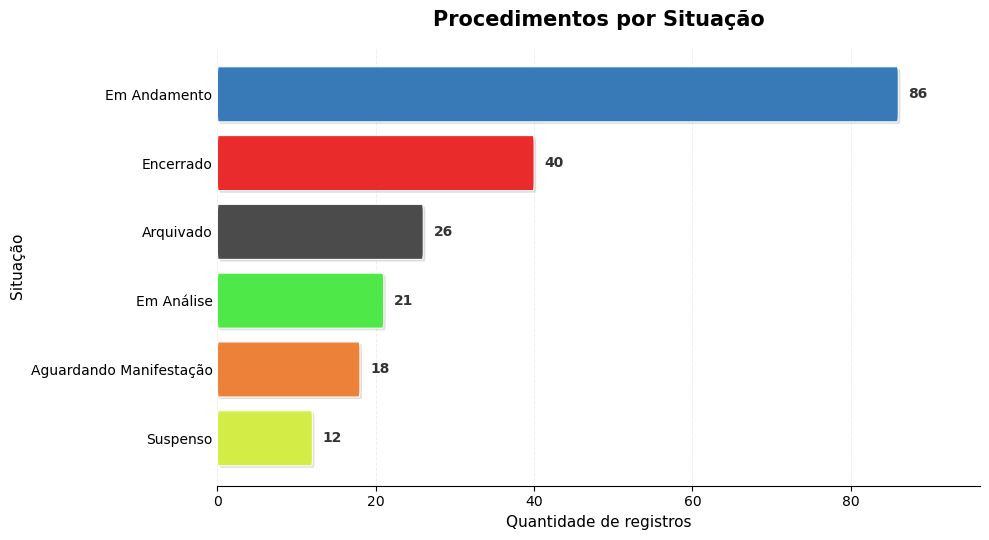

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import FancyBboxPatch

contagem = df_indicadores["situacao"].value_counts().sort_values()

cores_situacao = {
    "Em Andamento": "#2F75B5",
    "Em Análise": "#46EA40",
    "Aguardando Manifestação": "#ED7D31",
    "Suspenso": "#D4EE3E",
    "Encerrado": "#EA2121",
    "Arquivado": "#444343"
}

cores = [
    cores_situacao.get(situacao, "#A5A5A5")
    for situacao in contagem.index
]

fig, ax = plt.subplots(figsize=(10, 5.5))

# Criamos barras invisíveis apenas para obter posições e dimensões
barras_base = ax.barh(
    contagem.index,
    contagem.values,
    color="none",
    edgecolor="none"
)

# Substitui visualmente cada barra por uma barra arredondada
for barra, cor in zip(barras_base, cores):

    x = barra.get_x()
    y = barra.get_y()
    largura = barra.get_width()
    altura = barra.get_height()

    barra_arredondada = FancyBboxPatch(
        (x, y),
        largura,
        altura,
        boxstyle="round,pad=0,rounding_size=0.12",
        linewidth=0.8,
        edgecolor="white",
        facecolor=cor,
        alpha=0.95
    )

    # Sombra suave
    barra_arredondada.set_path_effects([
        pe.SimplePatchShadow(
            offset=(1.5, -1.5),
            alpha=0.15
        ),
        pe.Normal()
    ])

    ax.add_patch(barra_arredondada)

# Valores no final das barras
for barra, valor in zip(barras_base, contagem.values):
    ax.text(
        valor + contagem.max() * 0.015,
        barra.get_y() + barra.get_height() / 2,
        f"{valor}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

ax.set_title(
    "Procedimentos por Situação",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Quantidade de registros",
    fontsize=11
)

ax.set_ylabel(
    "Situação",
    fontsize=11
)

# Grid discreto
ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.20
)

ax.set_axisbelow(True)

# Remove bordas menos úteis
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Remove os pequenos traços do eixo Y
ax.tick_params(
    axis="y",
    length=0
)

# Espaço adicional para os valores
ax.set_xlim(
    0,
    contagem.max() * 1.12
)

fig.tight_layout()
plt.show()


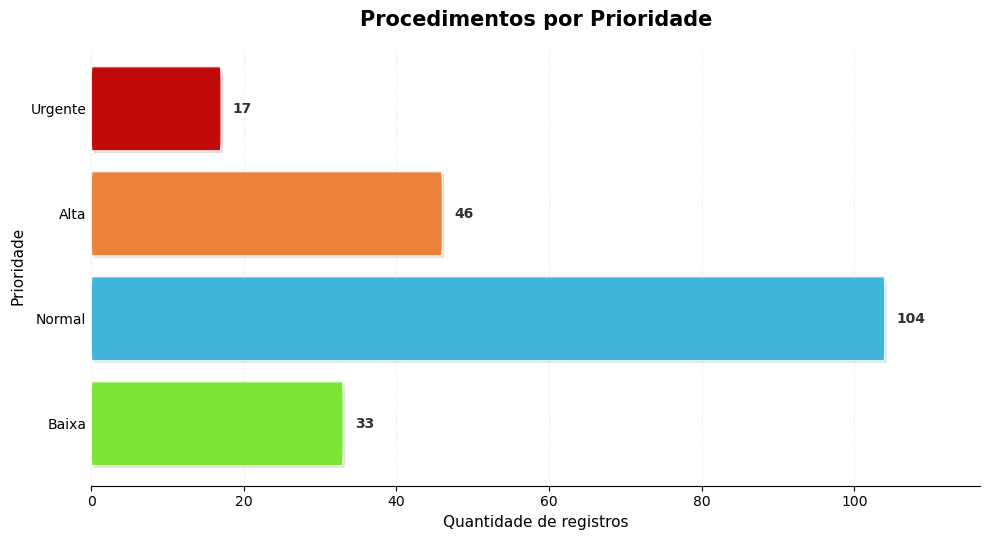

In [22]:
# Ordem lógica das prioridades
ordem_prioridade = [
    "Baixa",
    "Normal",
    "Alta",
    "Urgente"
]

contagem = (
    df_indicadores["prioridade"]
    .value_counts()
    .reindex(ordem_prioridade)
    .dropna()
)

# Paleta por nível de prioridade
cores_prioridade = {
    "Baixa": "#76E52C",      
    "Normal": "#39B3D9",    
    "Alta": "#ED7D31",       
    "Urgente": "#C00000"     
}

cores = [
    cores_prioridade.get(prioridade, "#A5A5A5")
    for prioridade in contagem.index
]

fig, ax = plt.subplots(figsize=(10, 5.5))

# Barras-base invisíveis para definir posição e tamanho
barras_base = ax.barh(
    contagem.index,
    contagem.values,
    color="none",
    edgecolor="none"
)

# Barras arredondadas
for barra, cor in zip(barras_base, cores):

    x = barra.get_x()
    y = barra.get_y()
    largura = barra.get_width()
    altura = barra.get_height()

    barra_arredondada = FancyBboxPatch(
        (x, y),
        largura,
        altura,
        boxstyle="round,pad=0,rounding_size=0.12",
        linewidth=0.8,
        edgecolor="white",
        facecolor=cor,
        alpha=0.95
    )

    # Sombra discreta
    barra_arredondada.set_path_effects([
        pe.SimplePatchShadow(
            offset=(1.5, -1.5),
            alpha=0.15
        ),
        pe.Normal()
    ])

    ax.add_patch(barra_arredondada)

# Valores ao lado das barras
for barra, valor in zip(barras_base, contagem.values):

    ax.text(
        valor + contagem.max() * 0.015,
        barra.get_y() + barra.get_height() / 2,
        f"{valor}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

# Título
ax.set_title(
    "Procedimentos por Prioridade",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Eixos
ax.set_xlabel(
    "Quantidade de registros",
    fontsize=11
)

ax.set_ylabel(
    "Prioridade",
    fontsize=11
)

# Grid discreto
ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.20
)

ax.set_axisbelow(True)

# Remove bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Remove pequenos traços ao lado das categorias
ax.tick_params(
    axis="y",
    length=0
)

# Espaço para os números
ax.set_xlim(
    0,
    contagem.max() * 1.12
)

fig.tight_layout()
plt.show()

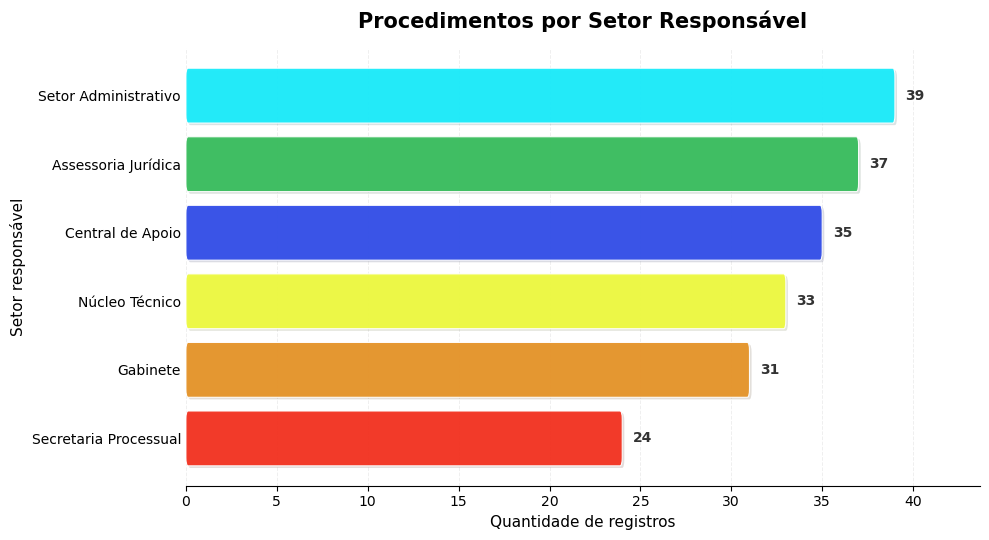

In [23]:
contagem = (
    df_indicadores["setor_responsavel"]
    .value_counts()
    .sort_values()
)

paleta_setores = [
    "#F3311F",
    "#E59328",
    "#EDF93F",
    "#314DE8",
    "#38BD5C",
    "#19EBFA",
    "#7F8C8D",
    "#A5A5A5"
]

# Repete a paleta caso existam mais setores do que cores
cores = [
    paleta_setores[i % len(paleta_setores)]
    for i in range(len(contagem))
]

fig, ax = plt.subplots(figsize=(10, 5.5))

# Barras-base invisíveis
barras_base = ax.barh(
    contagem.index,
    contagem.values,
    color="none",
    edgecolor="none"
)

# Cria barras arredondadas
for barra, cor in zip(barras_base, cores):

    x = barra.get_x()
    y = barra.get_y()
    largura = barra.get_width()
    altura = barra.get_height()

    barra_arredondada = FancyBboxPatch(
        (x, y),
        largura,
        altura,
        boxstyle="round,pad=0,rounding_size=0.12",
        linewidth=0.8,
        edgecolor="white",
        facecolor=cor,
        alpha=0.95
    )

    barra_arredondada.set_path_effects([
        pe.SimplePatchShadow(
            offset=(1.5, -1.5),
            alpha=0.15
        ),
        pe.Normal()
    ])

    ax.add_patch(barra_arredondada)

# Valores ao lado das barras
for barra, valor in zip(barras_base, contagem.values):

    ax.text(
        valor + contagem.max() * 0.015,
        barra.get_y() + barra.get_height() / 2,
        f"{valor}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

# Título
ax.set_title(
    "Procedimentos por Setor Responsável",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Eixos
ax.set_xlabel(
    "Quantidade de registros",
    fontsize=11
)

ax.set_ylabel(
    "Setor responsável",
    fontsize=11
)

# Grid discreto
ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.20
)

ax.set_axisbelow(True)

# Remove bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0
)

# Espaço para os valores
ax.set_xlim(
    0,
    contagem.max() * 1.12
)

fig.tight_layout()
plt.show()

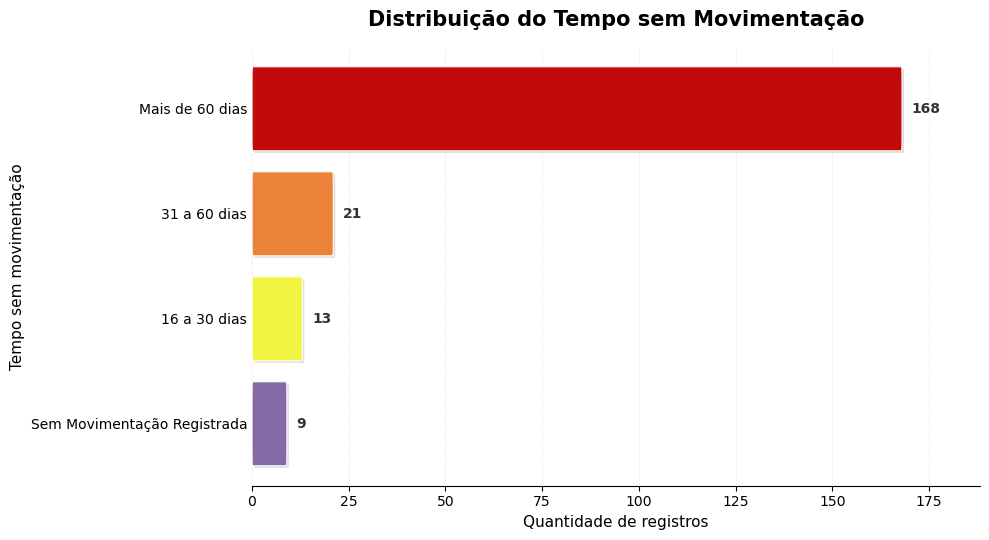

In [24]:
# Ordem lógica das faixas
ordem_tempo_parado = [
    "Sem Movimentação Registrada",
    "Até 7 dias",
    "8 a 15 dias",
    "16 a 30 dias",
    "31 a 60 dias",
    "Mais de 60 dias"
]

contagem = (
    df_indicadores["faixa_tempo_parado"]
    .value_counts()
)

# Mantém apenas as categorias realmente existentes,
# mas na ordem lógica definida acima
contagem = contagem.reindex(
    [
        faixa
        for faixa in ordem_tempo_parado
        if faixa in contagem.index
    ]
)

# Paleta baseada no nível de atenção
cores_tempo_parado = {
    "Até 7 dias": "#D9EAF7",                    # azul bem claro
    "8 a 15 dias": "#B4D7E8",                  # azul claro
    "16 a 30 dias": "#F1F539",                 # amarelo suave
    "31 a 60 dias": "#ED7D31",                 # laranja de alerta
    "Mais de 60 dias": "#C00000",              # vermelho crítico
    "Sem Movimentação Registrada": "#8064A2"   # roxo de atenção/exceção
}

cores = [
    cores_tempo_parado.get(faixa, "#A5A5A5")
    for faixa in contagem.index
]

fig, ax = plt.subplots(figsize=(10, 5.5))

# Barras-base invisíveis
barras_base = ax.barh(
    contagem.index,
    contagem.values,
    color="none",
    edgecolor="none"
)

# Barras arredondadas
for barra, cor in zip(barras_base, cores):

    x = barra.get_x()
    y = barra.get_y()
    largura = barra.get_width()
    altura = barra.get_height()

    barra_arredondada = FancyBboxPatch(
        (x, y),
        largura,
        altura,
        boxstyle="round,pad=0,rounding_size=0.12",
        linewidth=0.8,
        edgecolor="white",
        facecolor=cor,
        alpha=0.95
    )

    # Sombra discreta
    barra_arredondada.set_path_effects([
        pe.SimplePatchShadow(
            offset=(1.5, -1.5),
            alpha=0.15
        ),
        pe.Normal()
    ])

    ax.add_patch(barra_arredondada)

# Valores ao lado das barras
for barra, valor in zip(barras_base, contagem.values):

    ax.text(
        valor + contagem.max() * 0.015,
        barra.get_y() + barra.get_height() / 2,
        f"{valor}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

# Título
ax.set_title(
    "Distribuição do Tempo sem Movimentação",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Eixos
ax.set_xlabel(
    "Quantidade de registros",
    fontsize=11
)

ax.set_ylabel(
    "Tempo sem movimentação",
    fontsize=11
)

# Grid discreto
ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.20
)

ax.set_axisbelow(True)

# Remove bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0
)

# Espaço para os números
ax.set_xlim(
    0,
    contagem.max() * 1.12
)

fig.tight_layout()
plt.show()

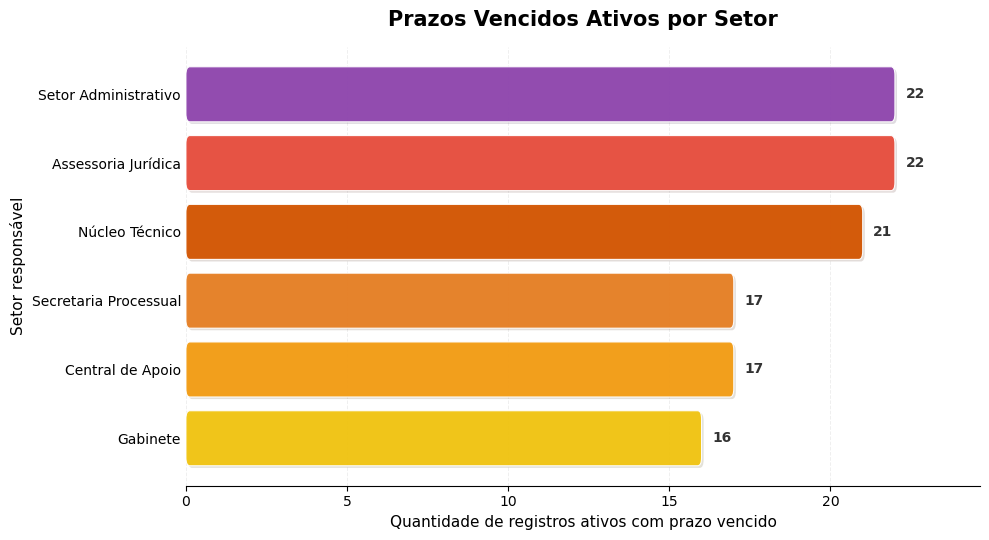

In [ ]:
contagem = (
    analise_setor["prazos_vencidos"]
    .sort_values()
)

# Gradiente de alerta:
# setores com mais prazos vencidos recebem tons mais intensos
paleta_alerta = [
    "#F1C40F",  
    "#F39C12",  
    "#E67E22",  
    "#D35400",  
    "#E74C3C", 
    "#C0392B",  
    "#8E44AD"   
]

# Distribui as cores conforme a posição no ranking
cores = [
    paleta_alerta[
        int(
            i * (len(paleta_alerta) - 1)
            / max(len(contagem) - 1, 1)
        )
    ]
    for i in range(len(contagem))
]

fig, ax = plt.subplots(figsize=(10, 5.5))

# Barras-base invisíveis
barras_base = ax.barh(
    contagem.index,
    contagem.values,
    color="none",
    edgecolor="none"
)

# Barras arredondadas
for barra, cor in zip(barras_base, cores):

    x = barra.get_x()
    y = barra.get_y()
    largura = barra.get_width()
    altura = barra.get_height()

    barra_arredondada = FancyBboxPatch(
        (x, y),
        largura,
        altura,
        boxstyle="round,pad=0,rounding_size=0.12",
        linewidth=0.8,
        edgecolor="white",
        facecolor=cor,
        alpha=0.95
    )

    barra_arredondada.set_path_effects([
        pe.SimplePatchShadow(
            offset=(1.5, -1.5),
            alpha=0.15
        ),
        pe.Normal()
    ])

    ax.add_patch(barra_arredondada)

# Valores ao final das barras
for barra, valor in zip(barras_base, contagem.values):

    ax.text(
        valor + max(contagem.max(), 1) * 0.015,
        barra.get_y() + barra.get_height() / 2,
        f"{int(valor)}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="#333333"
    )

# Título
ax.set_title(
    "Prazos Vencidos Ativos por Setor",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Eixos
ax.set_xlabel(
    "Quantidade de registros ativos com prazo vencido",
    fontsize=11
)

ax.set_ylabel(
    "Setor responsável",
    fontsize=11
)

# Grid discreto
ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.20
)

ax.set_axisbelow(True)

# Remove bordas desnecessárias
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis="y",
    length=0
)

# Espaço para os valores ao lado das barras
ax.set_xlim(
    0,
    max(contagem.max(), 1) * 1.12
)

fig.tight_layout()
plt.show()

## EXPORTAÇÃO DA BASE TRATADA

In [26]:
df.to_csv(
    "mp_controle_prazos_tratado.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)
print("Base tratada exportada: mp_controle_prazos_tratado.csv")

Base tratada exportada: mp_controle_prazos_tratado.csv


## CONCLUSÕES DO PROJETO

In [27]:
print("Data de referência:", data_referencia.date())
print(f"Base inicial: {len(df_bruto)} registros; base tratada: {len(df)} registros.")
print(f"Duplicatas exatas removidas após padronização: {qtd_duplicadas_exatas}.")
print(f"Registros com ID repetido mantidos: {df['id_repetido'].sum()}.")
print(f"Registros com alguma inconsistência sinalizada: {df['possui_inconsistencia'].sum()}.")

print("\nQualidade dos dados: quantidade por flag")
display(df[colunas_flags].sum().sort_values(ascending=False))
print("\nDatas ausentes ou inválidas, mantidas sem preenchimento")
display(df[colunas_data].isna().sum())
print("\nNúmeros ausentes ou não recuperáveis")
display(df[colunas_numericas].isna().sum())

print(f"Prazos vencidos em registros ativos: {total_prazos_vencidos}.")
print(f"Prazos próximos, em todas as situações: {total_prazos_proximos}.")
print(f"Registros há mais de 60 dias sem movimentação: {(df['dias_sem_movimentacao'] > 60).sum()}.")
print(f"Média de movimentações não negativas: {media_movimentacoes:.2f}.")

print("\nSetores com mais prazos vencidos ativos: pontos para investigação")
display(analise_setor.head(3))
print("As diferenças entre setores não demonstram ineficiência por si só.")

print("\nDistribuição da fila de atenção")
display(df["nivel_atencao"].value_counts())
print("A fila ajuda a ordenar a revisão; seus pesos são didáticos e não são regras oficiais.")
print("Datas, prazos divergentes, valores negativos e registros ambíguos foram mantidos para análise humana.")

Data de referência: 2026-10-07
Base inicial: 220 registros; base tratada: 211 registros.
Duplicatas exatas removidas após padronização: 9.
Registros com ID repetido mantidos: 2.
Registros com alguma inconsistência sinalizada: 104.

Qualidade dos dados: quantidade por flag


flag_categoria_inconsistente    63
flag_data_limite_sem_prazo      28
flag_prazo_sem_data_limite      15
flag_prazo_incoerente           14
flag_limite_antes_abertura       8
flag_mov_antes_abertura          6
flag_zero_mov_com_data           4
flag_id_invalido                 2
id_repetido                      2
flag_movimentacao_negativa       2
flag_data_futura                 0
dtype: Int64


Datas ausentes ou inválidas, mantidas sem preenchimento


data_abertura                8
data_ultima_movimentacao     9
data_limite                 17
dtype: int64


Números ausentes ou não recuperáveis


...

Prazos vencidos em registros ativos: 120.
Prazos próximos, em todas as situações: 8.
Registros há mais de 60 dias sem movimentação: 168.
Média de movimentações não negativas: 8.98.

Setores com mais prazos vencidos ativos: pontos para investigação


,total_procedimentos,media_dias_parado,prazos_vencidos,media_movimentacoes
setor_responsavel,,,,
Assessoria Jurídica,37,252.666667,22,9.027778
Setor Administrativo,39,260.923077,22,9.081081
Núcleo Técnico,33,246.727273,21,10.575758


As diferenças entre setores não demonstram ineficiência por si só.

Distribuição da fila de atenção


nivel_atencao
Atenção    124
Normal      61
Crítico     26
Name: count, dtype: int64

A fila ajuda a ordenar a revisão; seus pesos são didáticos e não são regras oficiais.
Datas, prazos divergentes, valores negativos e registros ambíguos foram mantidos para análise humana.
